# ☠️ Dead Men Tell No Tales  
### ☠️🍄 Poisonous Mushroom Classification

## 🍄 Mushroom Classification – Classical Machine Learning Benchmark

**Project Goal**  
Compare eight classical machine learning algorithms on the UCI Mushroom (Agaricus-Lepiota) dataset to predict whether a mushroom is **edible** or **poisonous**.  

**Dataset** [Mushroom Classification Dataset By UCIML](https://www.kaggle.com/datasets/uciml/mushroom-classification)

We evaluate models using 5-fold cross-validation and a held-out test set, then identify the best-performing classifier and analyze its predictions in detail.

**Models Compared**  
Logistic Regression · Decision Tree · Random Forest · Gradient Boosting · SVM (RBF) · K-Nearest Neighbors · Naive Bayes · Neural Network (MLP)

In [26]:
### 1. Imports

# We import the essential libraries:
#
# - **numpy & pandas** → numerical computing and data handling
# - **matplotlib & seaborn** → visualization
# - **scikit-learn** → model selection, preprocessing, metrics, and all classifiers

# `sns.set_style("whitegrid")` and `%matplotlib inline` make the plots look clean inside the notebook.
########**************************************************************************##################

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

sns.set_style("whitegrid")
%matplotlib inline

SyntaxError: invalid character '→' (U+2192) (2521037355.py, line 5)

### 2. Load the Mushroom Dataset

We load the classic **UCI Mushroom (Agaricus-Lepiota)** dataset directly from the UCI repository.

- **8124 samples**
- **22 categorical features** (cap shape, odor, gill color, habitat, etc.)
- **Binary target**:  
  - `e` = edible  
  - `p` = poisonous

The class distribution is almost perfectly balanced, which is ideal for classification experiments.

In [17]:
# Load Mushroom dataset from UCI
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/mushroom/agaricus-lepiota.data"
columns = [
    'class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor',
    'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color',
    'stalk-shape', 'stalk-root', 'stalk-surface-above-ring',
    'stalk-surface-below-ring', 'stalk-color-above-ring',
    'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number',
    'ring-type', 'spore-print-color', 'population', 'habitat'
]

df = pd.read_csv(url, header=None, names=columns)
print("Dataset shape:", df.shape)
print("\nClass distribution:")
print(df['class'].value_counts())
df.head()

Dataset shape: (8124, 23)

Class distribution:
class
e    4208
p    3916
Name: count, dtype: int64


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


### 3. Preprocessing

All features (and the target) are categorical strings.  
We convert every column to integers using `LabelEncoder`.

After encoding:
- `X` → feature matrix (8124 × 22)
- `y` → binary labels (0 = edible, 1 = poisonous)

We then perform a **stratified 80/20 train-test split** so that both sets keep the same class ratio.  
`random_state=42` makes the split reproducible.

In [18]:
# Encode all categorical features
le = LabelEncoder()
for col in df.columns:
    df[col] = le.fit_transform(df[col])

X = df.drop('class', axis=1)
y = df['class']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples:     {X_test.shape[0]}")

Training samples: 6499
Test samples:     1625


### 4. Define the Classifiers

We create a dictionary of **8 representative algorithms** covering the main families of classical machine learning:

| Family              | Model                        |
|---------------------|------------------------------|
| Linear              | Logistic Regression          |
| Tree                | Decision Tree                |
| Ensemble (Bagging)  | Random Forest                |
| Ensemble (Boosting) | Gradient Boosting            |
| Kernel              | SVM (RBF)                    |
| Instance-based      | K-Nearest Neighbors          |
| Probabilistic       | Gaussian Naive Bayes         |
| Neural Network      | Multi-Layer Perceptron (MLP) |

All models use a fixed `random_state` for reproducibility. Hyperparameters are kept at sensible defaults for a fair comparison.

In [19]:
classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "SVM (RBF)": SVC(kernel='rbf', random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    "Neural Network (MLP)": MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42)
}

### 5. Training + Test Evaluation

1. Train on the full training set and evaluate once on the held-out **test set**

Cross-validation gives a more reliable estimate of generalization performance.(for more see below)

In [20]:
results = []

print("Training classifiers one by one...\n")
print("-" * 55)

for name, model in classifiers.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    results.append({
        "Classifier": name,
        "Accuracy": round(acc * 100, 2)
    })

    print(f"{name:<25} → Test Accuracy: {acc*100:.2f}%")

print("-" * 55)

Training classifiers one by one...

-------------------------------------------------------
Logistic Regression       → Test Accuracy: 95.51%
Decision Tree             → Test Accuracy: 100.00%
Random Forest             → Test Accuracy: 100.00%
Gradient Boosting         → Test Accuracy: 100.00%
SVM (RBF)                 → Test Accuracy: 99.20%
K-Nearest Neighbors       → Test Accuracy: 99.69%
Naive Bayes               → Test Accuracy: 92.86%
Neural Network (MLP)      → Test Accuracy: 100.00%
-------------------------------------------------------


### Accuracy Comparison – Bar Plot

A horizontal bar plot of accuracies makes the ranking visual and easy to remember.


=== Accuracy Comparison ===
          Classifier  Accuracy
       Decision Tree    100.00
       Random Forest    100.00
   Gradient Boosting    100.00
Neural Network (MLP)    100.00
 K-Nearest Neighbors     99.69
           SVM (RBF)     99.20
 Logistic Regression     95.51
         Naive Bayes     92.86


/tmp/ipykernel_807/2359994639.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Accuracy", y="Classifier", palette="viridis")


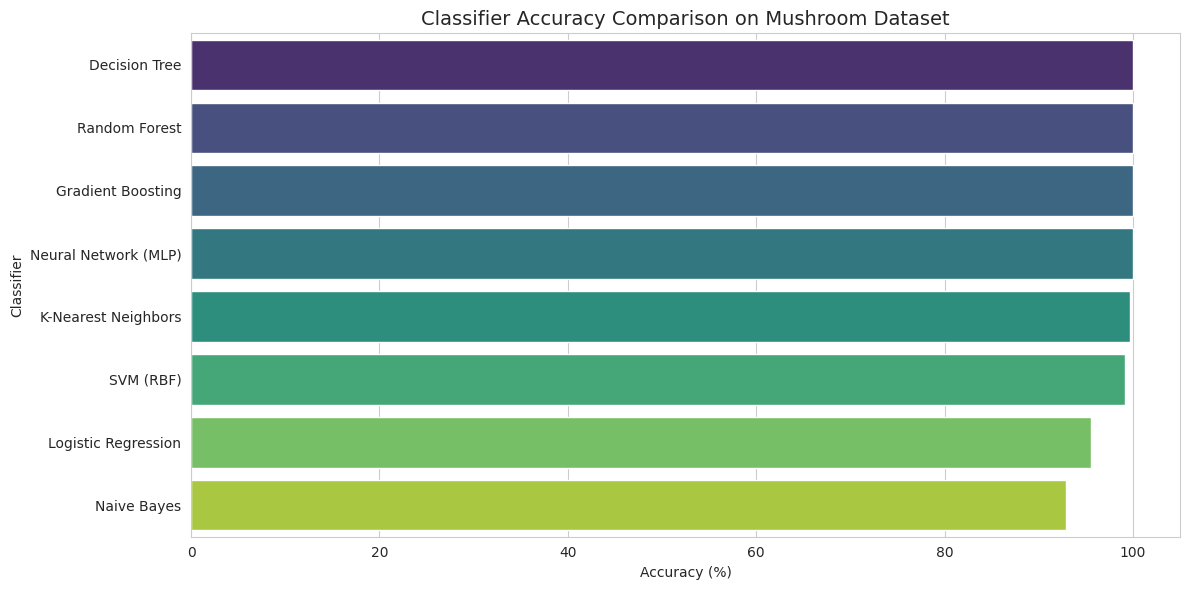

In [21]:
results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)
print("\n=== Accuracy Comparison ===")
print(results_df.to_string(index=False))

# Bar plot
plt.figure(figsize=(12, 6))
sns.barplot(data=results_df, x="Accuracy", y="Classifier", palette="viridis")
plt.title("Classifier Accuracy Comparison on Mushroom Dataset", fontsize=14)
plt.xlabel("Accuracy (%)")
plt.xlim(0, 105)
plt.tight_layout()
plt.show()

### 5. Training + 5-Fold Cross-Validation + Test Evaluation

For every classifier we perform two evaluations:

1. **5-Fold Cross-Validation** on the training set → mean accuracy ± standard deviation  
2. Train on the full training set and evaluate once on the held-out **test set**

Cross-validation gives a more reliable estimate of generalization performance.

In [22]:
results = []

print("Running 5-Fold Cross-Validation for each classifier...\n")
print("-" * 70)

for name, model in classifiers.items():
    # Cross-validation scores
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')

    # Also train on full training set and evaluate on test set
    model.fit(X_train, y_train)
    test_acc = accuracy_score(y_test, model.predict(X_test))

    results.append({
        "Classifier": name,
        "CV Mean Accuracy (%)": round(cv_scores.mean() * 100, 2),
        "CV Std (%)": round(cv_scores.std() * 100, 2),
        "Test Accuracy (%)": round(test_acc * 100, 2)
    })

    print(f"{name:<25} | CV: {cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100:.2f}% | Test: {test_acc*100:.2f}%")

print("-" * 70)

Running 5-Fold Cross-Validation for each classifier...

----------------------------------------------------------------------
Logistic Regression       | CV: 94.68% ± 0.35% | Test: 95.51%
Decision Tree             | CV: 100.00% ± 0.00% | Test: 100.00%
Random Forest             | CV: 100.00% ± 0.00% | Test: 100.00%
Gradient Boosting         | CV: 100.00% ± 0.00% | Test: 100.00%
SVM (RBF)                 | CV: 98.82% ± 0.28% | Test: 99.20%
K-Nearest Neighbors       | CV: 99.75% ± 0.20% | Test: 99.69%
Naive Bayes               | CV: 91.71% ± 0.97% | Test: 92.86%
Neural Network (MLP)      | CV: 100.00% ± 0.00% | Test: 100.00%
----------------------------------------------------------------------


### 6. Final Comparison Table

We collect all results into a pandas DataFrame, sort by **Cross-Validation Mean Accuracy**, and display a clean ranking table.

Sorting by CV score (not test score) is the correct way to rank models, because the test set was never used for model selection.

In [23]:
results_df = pd.DataFrame(results).sort_values(by="CV Mean Accuracy (%)", ascending=False)
print("\n=== Final Comparison Table ===")
print(results_df.to_string(index=False))


=== Final Comparison Table ===
          Classifier  CV Mean Accuracy (%)  CV Std (%)  Test Accuracy (%)
       Decision Tree                100.00        0.00             100.00
       Random Forest                100.00        0.00             100.00
   Gradient Boosting                100.00        0.00             100.00
Neural Network (MLP)                100.00        0.00             100.00
 K-Nearest Neighbors                 99.75        0.20              99.69
           SVM (RBF)                 98.82        0.28              99.20
 Logistic Regression                 94.68        0.35              95.51
         Naive Bayes                 91.71        0.97              92.86


### 7. Accuracy Comparison with Cross-Validation – Bar Plot

A horizontal bar plot of the 5-fold CV mean accuracies makes the ranking visual and easy to remember.

The x-axis is zoomed to **90–101%** because every model is already very strong on this dataset; otherwise the differences would be hard to see.

/tmp/ipykernel_807/3054227947.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


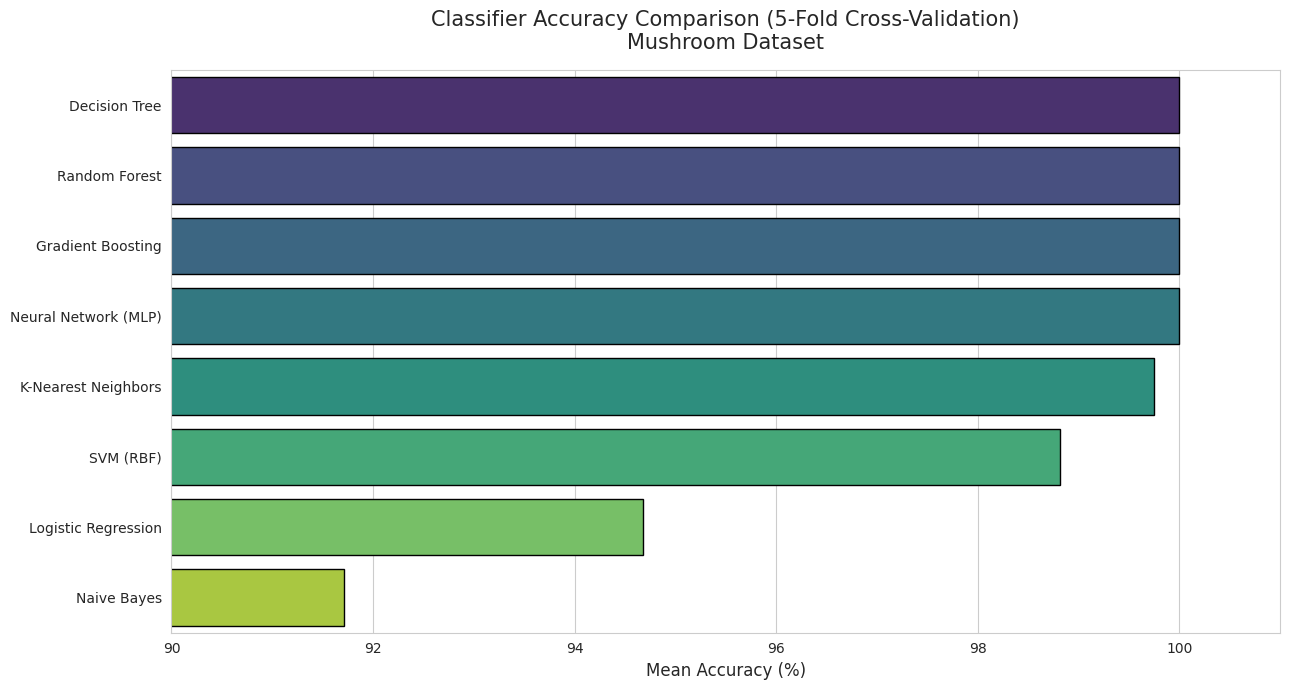

In [24]:
plt.figure(figsize=(13, 7))

# Plot CV Mean Accuracy
sns.barplot(
    data=results_df,
    x="CV Mean Accuracy (%)",
    y="Classifier",
    palette="viridis",
    edgecolor="black"
)

plt.title("Classifier Accuracy Comparison (5-Fold Cross-Validation)\nMushroom Dataset", fontsize=15, pad=15)
plt.xlabel("Mean Accuracy (%)", fontsize=12)
plt.ylabel("")
plt.xlim(90, 101)   # Most models are very high on this dataset
plt.tight_layout()
plt.show()

### 8. Best Model – Detailed Analysis

We select the top model according to cross-validation accuracy, retrain it, and produce:

- Full **Classification Report** (Precision, Recall, F1-score)
- **Confusion Matrix** heatmap

Even when accuracy is near 100%, the confusion matrix tells us *which* mistakes (if any) the model still makes.  
In a safety-critical domain like mushroom classification, a false negative (calling a poisonous mushroom edible) is far more dangerous than a false positive.

Best Model according to CV: Decision Tree

Classification Report on Test Set:
              precision    recall  f1-score   support

      Edible       1.00      1.00      1.00       842
   Poisonous       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



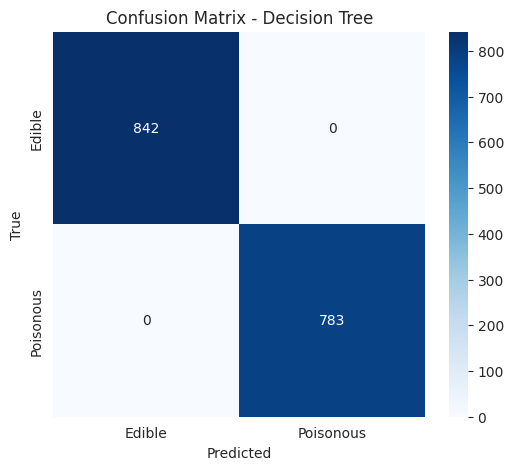

In [25]:
best_name = results_df.iloc[0]["Classifier"]
best_model = classifiers[best_name]
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

print(f"Best Model according to CV: {best_name}")
print("\nClassification Report on Test Set:")
print(classification_report(y_test, y_pred, target_names=["Edible", "Poisonous"]))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Edible", "Poisonous"],
            yticklabels=["Edible", "Poisonous"])
plt.title(f"Confusion Matrix - {best_name}")
plt.ylabel("True")
plt.xlabel("Predicted")
plt.show()

### Overall Key Takeaways

1. **Categorical data** must be encoded before feeding it to most scikit-learn models. `LabelEncoder` is the simplest solution.
2. **Stratified train-test split + Cross-Validation** is the proper way to evaluate and compare models.
3. On the Mushroom dataset other than **Neural Network** (MLP), **ensemble methods** (Random Forest, Gradient Boosting) and **Tree methods** (Decision Tree) usually dominate.
4. Near-perfect accuracy is possible, but **domain cost** still matters — misclassifying a poisonous mushroom is dangerous.
5. The same scikit-learn interface works from Logistic Regression all the way to a neural network — this uniformity is extremely powerful for teaching and experimentation.